In [1]:
import os
import sys
import subprocess
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score)

from car_color_utils import (
    load_dvm_dataset,
    CarColorDataset,
    CustomResNet,
    make_pretrained_resnet18,
    test_transform,
)

from tqdm import tqdm as tqdm_nb

In [2]:
def run(cmd):
    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        universal_newlines=True,
        encoding='utf-8',
        errors='replace',
        env={**os.environ, 'PYTHONUNBUFFERED': '1'},
    )
    
    for line in process.stdout:
        print(line, end='', flush=True)
    
    process.wait()
    
    if process.returncode != 0:
        print(f"\n The process exit with the code {process.returncode}")
    else:
        print(f"\n Training completed successfully!")
    
    return process.returncode


if not os.path.exists('training_output/model_scratch.pth') or \
   not os.path.exists('training_output/model_pretrained.pth'):
    print("No models found - starting training...\n")
    run([sys.executable, '-u', 'train_models.py'])
else:
    print("The models have already been trained.")

The models have already been trained.


In [3]:

OUTPUT_DIR = 'training_output'

with open(os.path.join(OUTPUT_DIR, 'meta.json')) as f:
    meta = json.load(f)

color_names    = meta['color_names']
color_to_idx   = meta['color_to_idx']
num_classes    = meta['num_classes']
best_f1_scratch    = meta['best_f1_scratch']
best_f1_pretrained = meta['best_f1_pretrained']

print(f"Classes ({num_classes}): {color_names}")
print(f"Best val F1  scratch    = {best_f1_scratch:.4f}")
print(f"Best val F1  pretrained = {best_f1_pretrained:.4f}")

with open(os.path.join(OUTPUT_DIR, 'history_scratch.json')) as f:
    history_scratch = json.load(f)
    
with open(os.path.join(OUTPUT_DIR, 'history_pretrained.json')) as f:
    history_pretrained = json.load(f)

with open(os.path.join(OUTPUT_DIR, 'split.json')) as f:
    split = json.load(f)

test_paths  = split['test_paths']
test_labels = split['test_labels']
val_paths   = split['val_paths']
val_labels  = split['val_labels']
train_paths = split['train_paths']
train_labels = split['train_labels']

print(f"\nTrain: {len(train_paths)}, Val: {len(val_paths)}, "
      f"Test: {len(test_paths)}")

Classes (9): ['black', 'blue', 'brown', 'gold', 'green', 'red', 'silver', 'white', 'yellow']
Best val F1  scratch    = 0.8364
Best val F1  pretrained = 0.8612

Train: 38312, Val: 9579, Test: 11973


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_scratch = CustomResNet(num_classes=num_classes)
model_scratch.load_state_dict(
    torch.load(os.path.join(OUTPUT_DIR, 'model_scratch.pth'),
               map_location='cpu'))

model_scratch = model_scratch.to(device).eval()
print(f"CustomResNet was loaded "
      f"({sum(p.numel() for p in model_scratch.parameters()):,} params)")

model_pretrained = make_pretrained_resnet18(num_classes)
model_pretrained.load_state_dict(
    torch.load(os.path.join(OUTPUT_DIR, 'model_pretrained.pth'),
               map_location='cpu'))
model_pretrained = model_pretrained.to(device).eval()

print(f"ResNet-18 was loaded "
      f"({sum(p.numel() for p in model_pretrained.parameters()):,} params)")

Device: cuda
CustomResNet was loaded (2,814,409 params)


c:\Users\dusti\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\dusti\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet-18 was loaded (11,181,129 params)


In [5]:
DATA_DIR = 'confirmed_fronts'

(all_paths, all_labels, all_colors,
 all_meta, _, _) = load_dvm_dataset(DATA_DIR, min_samples_per_class=500)

df = pd.DataFrame({
    'image_path': all_paths,
    'color':  all_colors,
    'label':  all_labels,
    'brand':  [m['brand'] for m in all_meta],
    'year':   [m['year']  for m in all_meta],
})

print(df['color'].value_counts())

Loading DVM dataset...


100%|██████████| 63/63 [00:01<00:00, 43.39it/s]


Images found with color tags: 59864

Color distribution:
  silver: 17081
  black: 14135
  white: 9300
  blue: 8378
  red: 6036
  gold: 2042
  brown: 1449
  green: 777
  yellow: 666

Classes: 9: ['black', 'blue', 'brown', 'gold', 'green', 'red', 'silver', 'white', 'yellow']
Total images count: 59864
color
silver    17081
black     14135
white      9300
blue       8378
red        6036
gold       2042
brown      1449
green       777
yellow      666
Name: count, dtype: int64


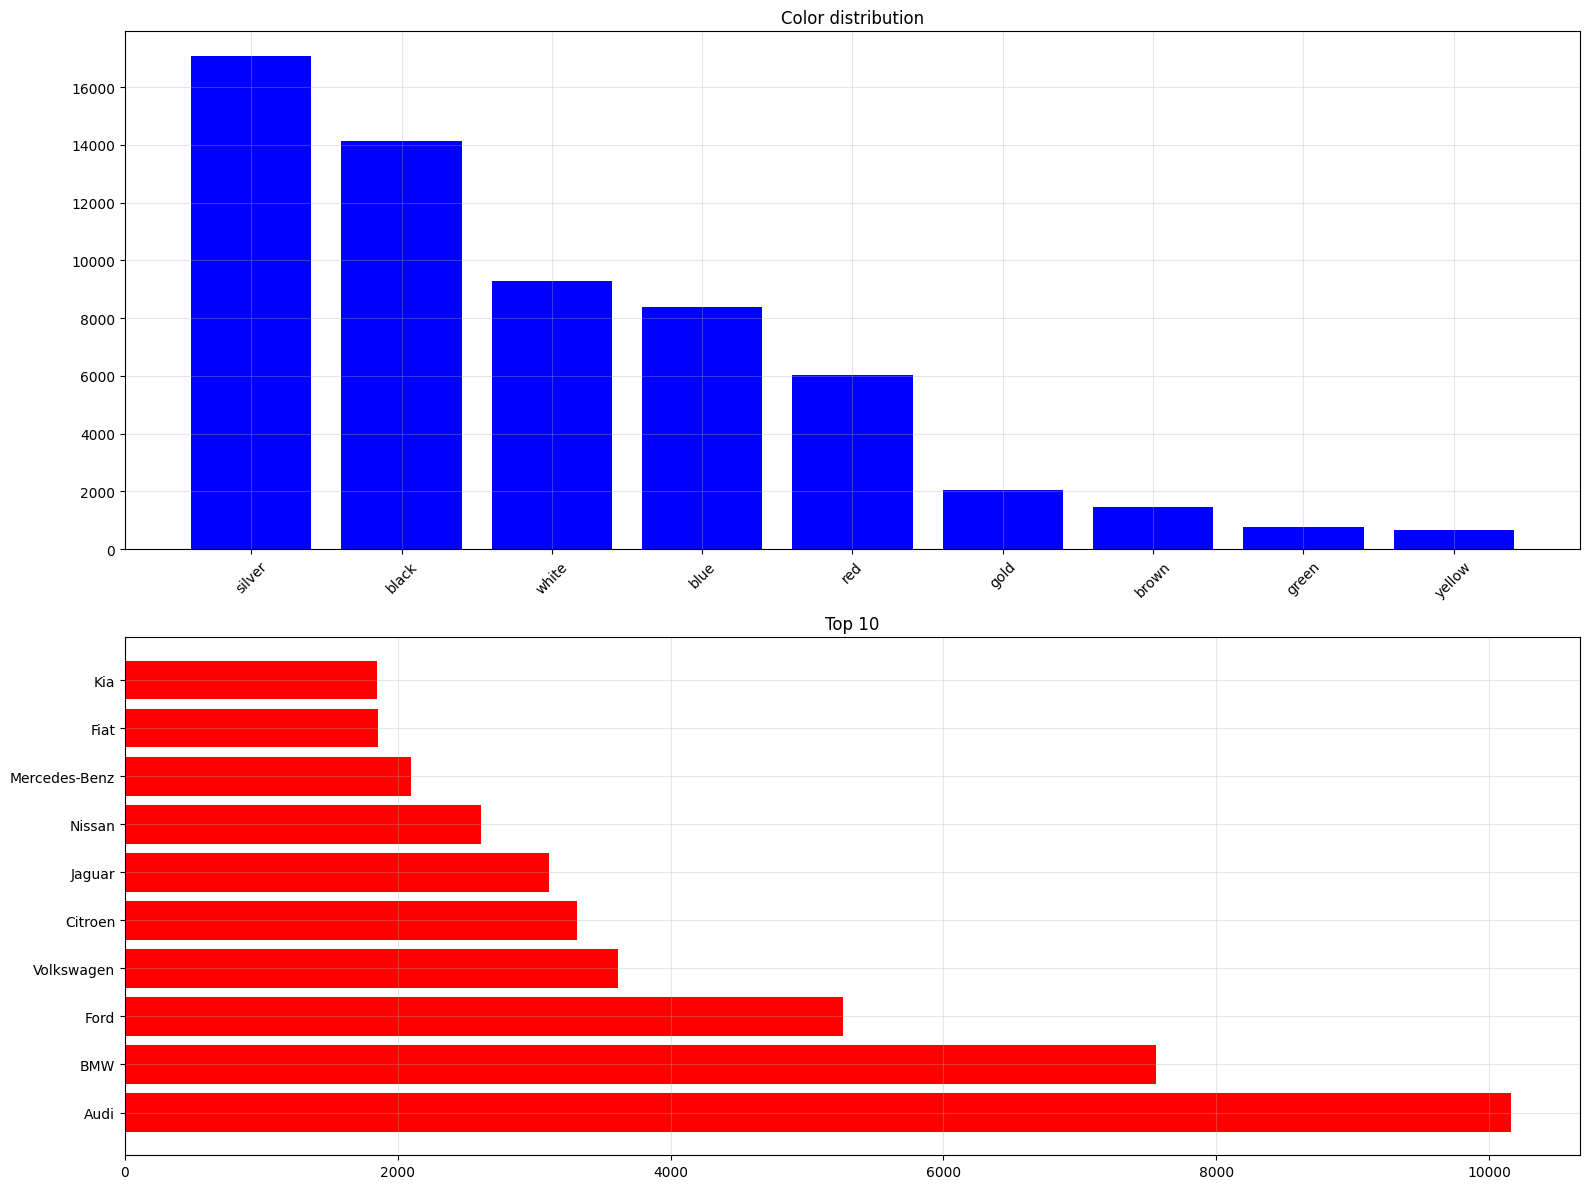

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

cc = df['color'].value_counts()
axes[0].bar(cc.index, cc.values, color='blue')
axes[0].set_title('Color distribution')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

bc = df['brand'].value_counts().head(10)
axes[1].barh(bc.index, bc.values, color='red')
axes[1].set_title('Top 10')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss = 0.0
    all_p, all_l = [], []

    with torch.inference_mode():
        for imgs, labs in tqdm_nb(loader, desc='eval'):
            imgs, labs = imgs.to(device), labs.to(device)
            out = model(imgs)
            running_loss += criterion(out, labs).item()
            all_p.extend(out.argmax(1).cpu().numpy())
            all_l.extend(labs.cpu().numpy())
    n = len(all_l)

    return (running_loss / len(loader),
            100. * np.sum(np.array(all_p) == np.array(all_l)) / n,
            f1_score(all_l, all_p, average='macro'),
            all_p, all_l)

test_loader = DataLoader(
    CarColorDataset(test_paths, test_labels, test_transform),
    batch_size=64, shuffle=False, num_workers=0)

print("Test - scratch")

tl_s, ta_s, tf_s, preds_s, labels_t = evaluate(
    model_scratch, test_loader, device)

print(f"  loss={tl_s:.4f}  acc={ta_s:.2f}%  F1={tf_s:.4f}\n")

print("Test - pretrained")

tl_p, ta_p, tf_p, preds_p, _ = evaluate(
    model_pretrained, test_loader, device)

print(f"  loss={tl_p:.4f}  acc={ta_p:.2f}%  F1={tf_p:.4f}")

Test - scratch


eval: 100%|██████████| 188/188 [01:45<00:00,  1.78it/s]


  loss=0.7383  acc=89.02%  F1=0.8204

Test - pretrained


eval: 100%|██████████| 188/188 [00:23<00:00,  8.06it/s]

  loss=0.3280  acc=92.14%  F1=0.8552


In [8]:
print("="*60, "\nScratch\n", "="*60)
print(classification_report(labels_t, preds_s,
                            target_names=color_names, digits=4))

print("="*60, "\nPretrained\n", "="*60)
print(classification_report(labels_t, preds_p,
                            target_names=color_names, digits=4))

Scratch
              precision    recall  f1-score   support

       black     0.8941    0.9197    0.9067      2827
        blue     0.9250    0.8837    0.9039      1676
       brown     0.5469    0.8448    0.6640       290
        gold     0.6617    0.6504    0.6560       409
       green     0.4979    0.7677    0.6041       155
         red     0.9650    0.9602    0.9626      1207
      silver     0.9234    0.8437    0.8818      3416
       white     0.9403    0.9575    0.9489      1860
      yellow     0.7862    0.9398    0.8562       133

    accuracy                         0.8902     11973
   macro avg     0.7934    0.8631    0.8204     11973
weighted avg     0.8985    0.8902    0.8925     11973

Pretrained
              precision    recall  f1-score   support

       black     0.9149    0.9512    0.9327      2827
        blue     0.9205    0.9123    0.9164      1676
       brown     0.7578    0.6690    0.7106       290
        gold     0.7493    0.6210    0.6791       409
     

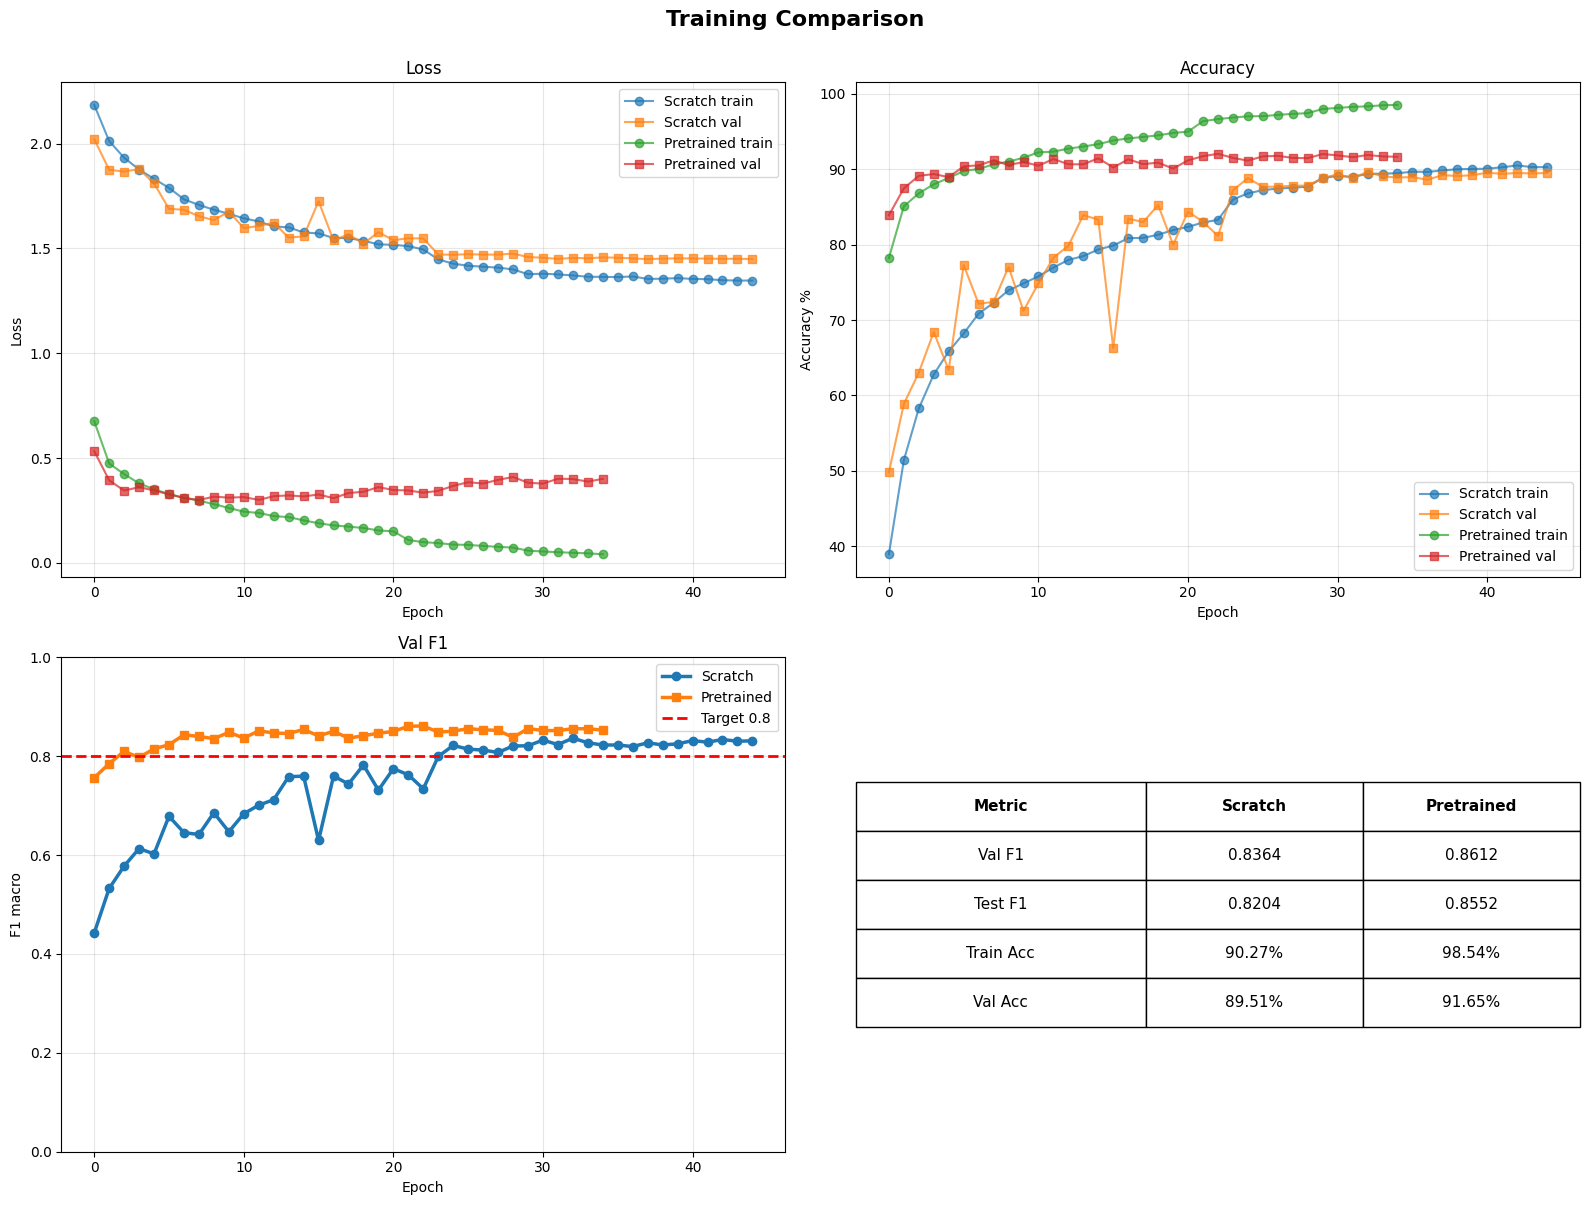

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

hs, hp = history_scratch, history_pretrained

axes[0,0].plot(hs['train_loss'], 'o-', label='Scratch train', alpha=.7)
axes[0,0].plot(hs['val_loss'],   's-', label='Scratch val',   alpha=.7)
axes[0,0].plot(hp['train_loss'], 'o-', label='Pretrained train', alpha=.7)
axes[0,0].plot(hp['val_loss'],   's-', label='Pretrained val',   alpha=.7)
axes[0,0].set(xlabel='Epoch', ylabel='Loss',
              title='Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=.3)

axes[0,1].plot(hs['train_acc'], 'o-', label='Scratch train', alpha=.7)
axes[0,1].plot(hs['val_acc'],   's-', label='Scratch val',   alpha=.7)
axes[0,1].plot(hp['train_acc'], 'o-', label='Pretrained train', alpha=.7)
axes[0,1].plot(hp['val_acc'],   's-', label='Pretrained val',   alpha=.7)
axes[0,1].set(xlabel='Epoch', ylabel='Accuracy %',
              title='Accuracy'); axes[0,1].legend(); axes[0,1].grid(alpha=.3)

axes[1,0].plot(hs['val_f1'], 'o-', lw=2.5, label='Scratch')
axes[1,0].plot(hp['val_f1'], 's-', lw=2.5, label='Pretrained')
axes[1,0].axhline(0.8, color='r', ls='--', lw=2, label='Target 0.8')
axes[1,0].set(xlabel='Epoch', ylabel='F1 macro', ylim=[0,1],
              title='Val F1'); axes[1,0].legend(); axes[1,0].grid(alpha=.3)

rows = [
    ['Metric', 'Scratch', 'Pretrained'],
    ['Val F1',    f'{best_f1_scratch:.4f}', f'{best_f1_pretrained:.4f}'],
    ['Test F1',        f"{tf_s:.4f}", f"{tf_p:.4f}"],
    ['Train Acc',f"{hs['train_acc'][-1]:.2f}%", f"{hp['train_acc'][-1]:.2f}%"],
    ['Val Acc',  f"{hs['val_acc'][-1]:.2f}%",   f"{hp['val_acc'][-1]:.2f}%"],
    
]

axes[1,1].axis('off')

tbl = axes[1,1].table(cellText=rows, cellLoc='center', loc='center',
                       colWidths=[.4,.3,.3])

tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2.5)

for i in range(3):
    tbl[(0,i)].set_text_props(weight='bold', color='black')
    
best_col = 1 if best_f1_scratch > best_f1_pretrained else 2

plt.suptitle('Training Comparison', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

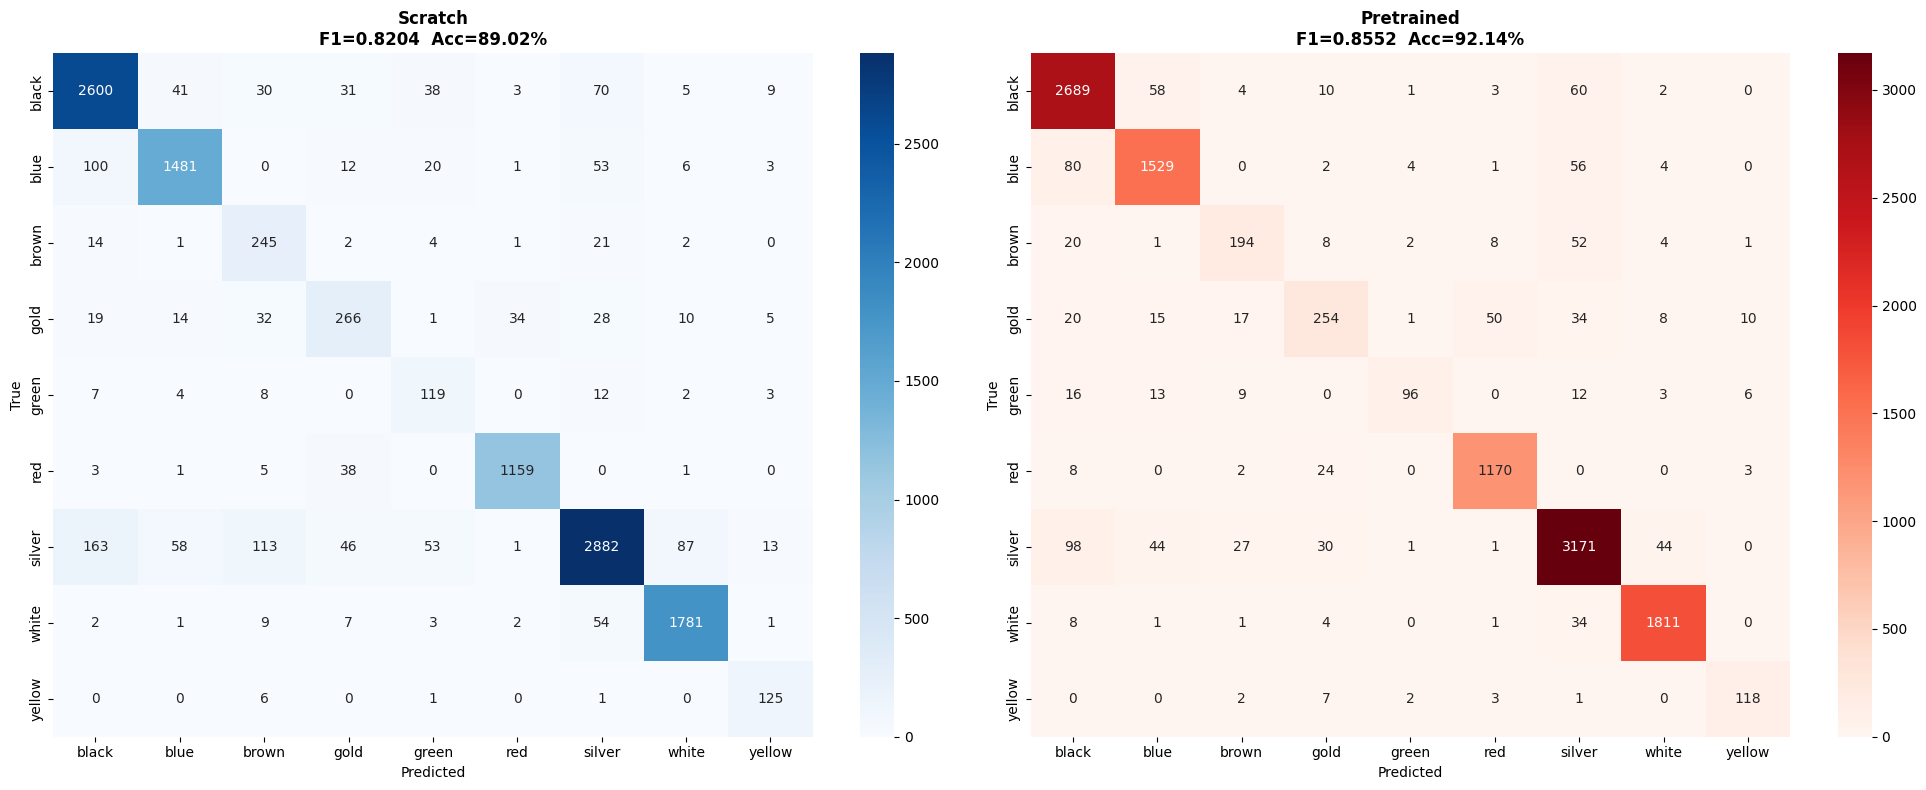

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_s = confusion_matrix(labels_t, preds_s)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
            xticklabels=color_names, yticklabels=color_names, ax=axes[0])

axes[0].set_title(f'Scratch\nF1={tf_s:.4f}  Acc={ta_s:.2f}%',
                  fontweight='bold')
axes[0].set(ylabel='True', xlabel='Predicted')

cm_p = confusion_matrix(labels_t, preds_p)
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Reds',
            xticklabels=color_names, yticklabels=color_names, ax=axes[1])
axes[1].set_title(f'Pretrained\nF1={tf_p:.4f}  Acc={ta_p:.2f}%',
                  fontweight='bold')
axes[1].set(ylabel='True', xlabel='Predicted')

plt.tight_layout()
plt.show()

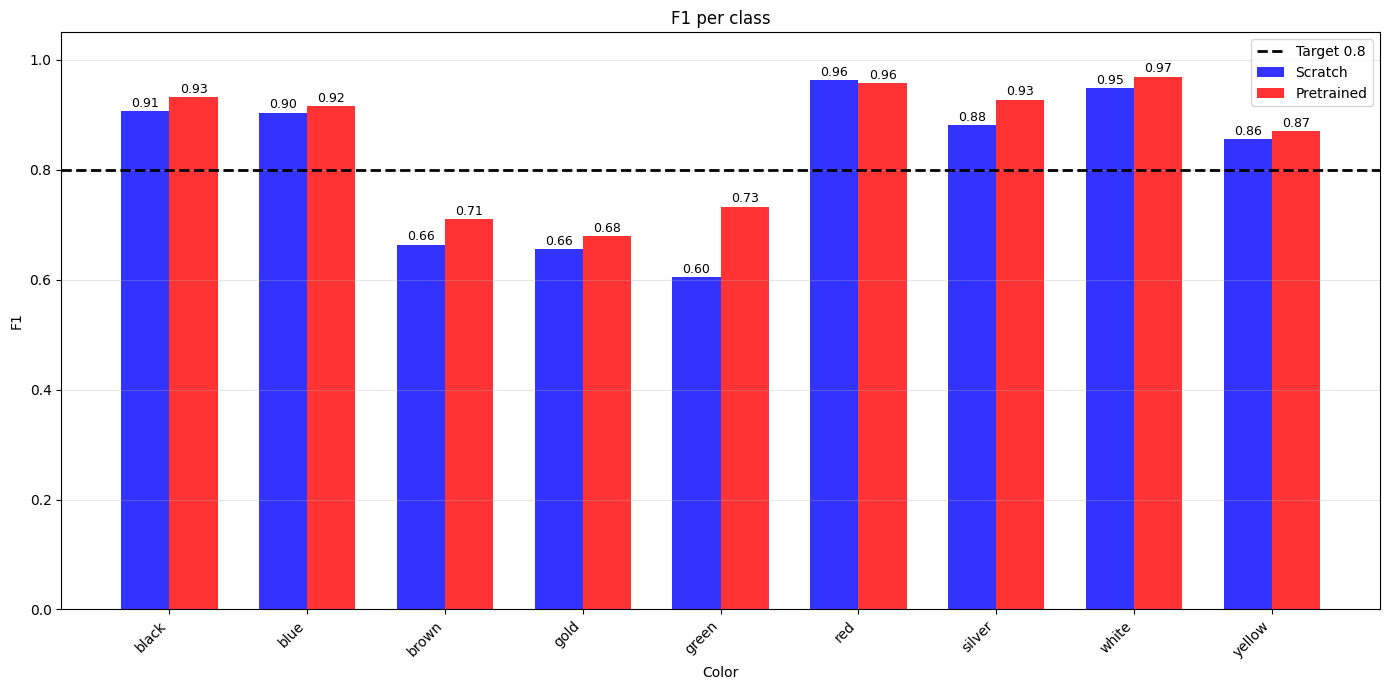

In [23]:
f1_s = f1_score(labels_t, preds_s, average=None)
f1_p = f1_score(labels_t, preds_p, average=None)

x = np.arange(len(color_names))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

b1 = ax.bar(x - w/2, f1_s, w, label='Scratch',    alpha=.8, color='blue')
b2 = ax.bar(x + w/2, f1_p, w, label='Pretrained', alpha=.8, color='red')

ax.axhline(0.8, color='black', ls='--', lw=2, label='Target 0.8')
ax.set(xticks=x, ylim=[0, 1.05], xlabel='Color', ylabel='F1',
       title='F1 per class')

ax.set_xticklabels(color_names, rotation=45, ha='right')
ax.legend(); ax.grid(alpha=.3, axis='y')

for bars in (b1, b2):
    for b in bars:
        ax.annotate(f'{b.get_height():.2f}',
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=9)
plt.tight_layout()
plt.show()

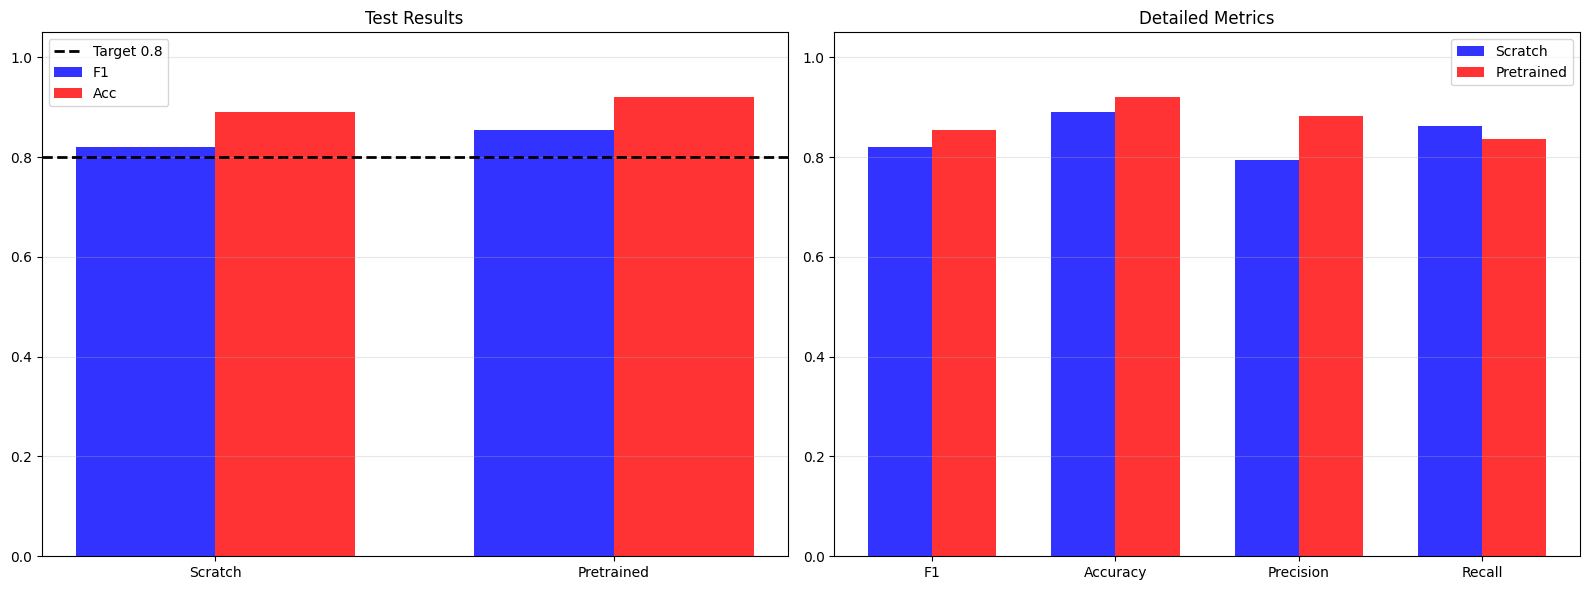

In [22]:
prec_s = precision_score(labels_t, preds_s, average='macro')
prec_p = precision_score(labels_t, preds_p, average='macro')
rec_s  = recall_score(labels_t, preds_s, average='macro')
rec_p  = recall_score(labels_t, preds_p, average='macro')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
w = 0.35

names = ['Scratch', 'Pretrained']
x1 = np.arange(2)
axes[0].bar(x1 - w/2, [tf_s, tf_p], w, label='F1',  color='blue', alpha=.8)
axes[0].bar(x1 + w/2, [ta_s/100, ta_p/100], w, label='Acc', color='red', alpha=.8)
axes[0].axhline(0.8, color='black', ls='--', lw=2, label='Target 0.8')
axes[0].set(xticks=x1, ylim=[0,1.05], title='Test Results')
axes[0].set_xticklabels(names); axes[0].legend(); axes[0].grid(alpha=.3, axis='y')

metrics = ['F1', 'Accuracy', 'Precision', 'Recall']

sv = [tf_s, ta_s/100, prec_s, rec_s]
pv = [tf_p, ta_p/100, prec_p, rec_p]
x2 = np.arange(4)

axes[1].bar(x2 - w/2, sv, w, label='Scratch',    color='blue', alpha=.8)
axes[1].bar(x2 + w/2, pv, w, label='Pretrained', color='red',     alpha=.8)
axes[1].set(xticks=x2, ylim=[0,1.05], title='Detailed Metrics')
axes[1].set_xticklabels(metrics); axes[1].legend(); axes[1].grid(alpha=.3, axis='y')

plt.tight_layout()
plt.show()